In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/model_ready_data.csv"
)

df.head()

,datetime,total_demand_kwh,hour,day,month,weekday,is_weekend,season,lag_1,lag_48,lag_96,rolling_mean_48,rolling_std_48
0,2013-01-03 00:00:00,209.864,0,3,1,3,0,0,243.522,198.338,220.013,240.736854,91.920733
1,2013-01-03 00:30:00,175.020,0,3,1,3,0,0,209.864,165.862,204.270,240.927646,91.771399
2,2013-01-03 01:00:00,151.394,1,3,1,3,0,0,175.020,147.971,189.439,240.998958,91.698930
3,2013-01-03 01:30:00,137.672,1,3,1,3,0,0,151.394,129.889,173.019,241.161104,91.504956
4,2013-01-03 02:00:00,128.217,2,3,1,3,0,0,137.672,117.542,154.537,241.383500,91.210616


In [2]:
features = [
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "season",
    "lag_1",
    "lag_48",
    "lag_96",
    "rolling_mean_48",
    "rolling_std_48"
]

X = df[features]

y = df["total_demand_kwh"]

In [3]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
predictions = model.predict(X_test)

In [6]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 10.745463894882375
RMSE: 13.777717804173083
R²: 0.9712555106748398


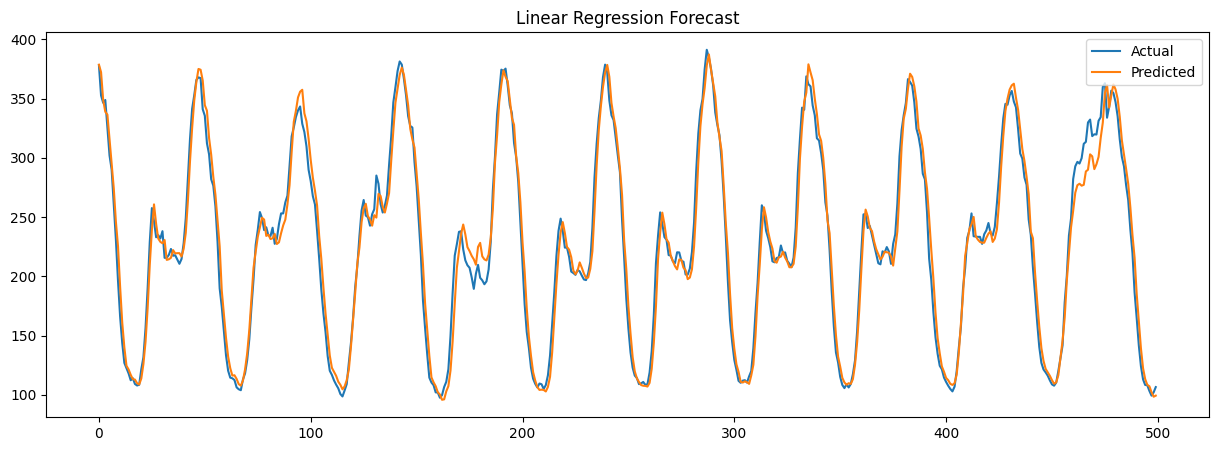

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    predictions[:500],
    label="Predicted"
)

plt.legend()

plt.title(
    "Linear Regression Forecast"
)

plt.show()

In [8]:
df["datetime"] = pd.to_datetime(
    df["datetime"]
)

df = (
    df
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Dataset:", df.shape)
print(df["datetime"].min())
print(df["datetime"].max())

Dataset: (20209, 13)
2013-01-03 00:00:00
2014-02-28 00:00:00


In [9]:
print(df[features + ["total_demand_kwh"]].isnull().sum())

df = df.dropna(
    subset=features + ["total_demand_kwh"]
)

hour                0
day                 0
month               0
weekday             0
is_weekend          0
season              0
lag_1               0
lag_48              0
lag_96              0
rolling_mean_48     0
rolling_std_48      0
total_demand_kwh    0
dtype: int64


In [10]:
from sklearn.metrics import mean_absolute_percentage_error

mape = (
    mean_absolute_percentage_error(
        y_test,
        predictions
    ) * 100
)

print("MAPE:", mape)

MAPE: 5.029935787471167


In [11]:
metrics = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ],

    "Value":[
        mae,
        rmse,
        mape,
        r2
    ]

})

metrics.to_csv(
    "../outputs/tables/linear_regression_metrics.csv",
    index=False
)

display(metrics)

,Metric,Value
0,MAE,10.745464
1,RMSE,13.777718
2,MAPE,5.029936
3,R2,0.971256


In [12]:
results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":predictions

})

display(results.head())

results.to_csv(
    "../outputs/tables/linear_predictions.csv",
    index=False
)

,Actual,Predicted
16167,378.081,378.568757
16168,352.589,372.221458
16169,346.410,348.799038
16170,348.800,338.836911
16171,325.244,336.407215


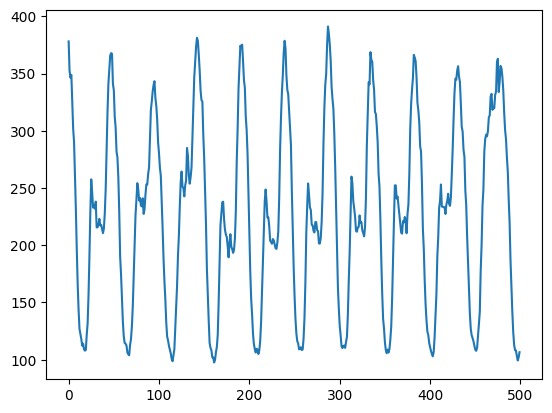

In [13]:
plt.plot(
    y_test.values[:500]
)

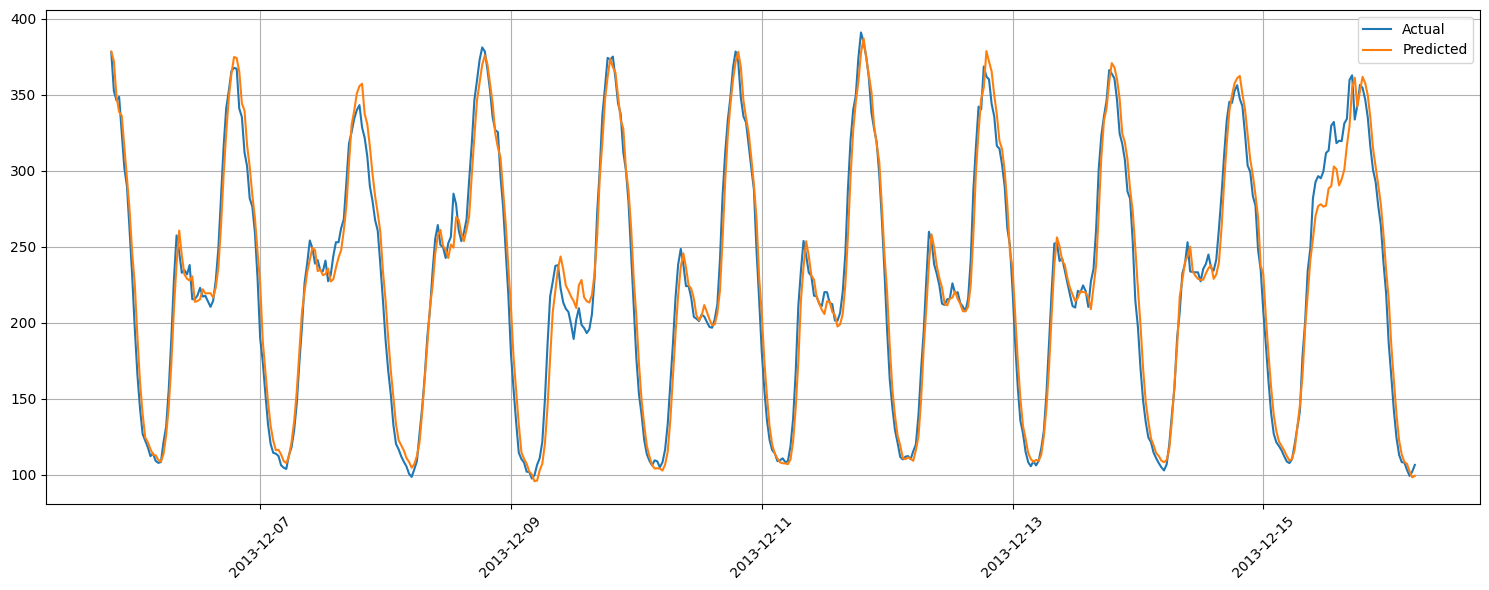

In [14]:
test_dates = df.iloc[
    split_index:
]["datetime"]

plt.figure(figsize=(15,6))

plt.plot(
    test_dates[:500],
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    test_dates[:500],
    predictions[:500],
    label="Predicted"
)

plt.legend()

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

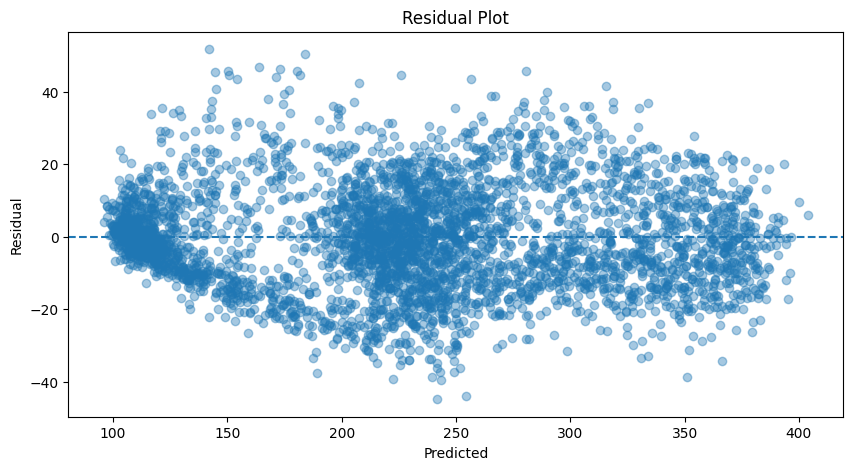

In [15]:
residuals = y_test - predictions

plt.figure(figsize=(10,5))

plt.scatter(
    predictions,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title(
    "Residual Plot"
)

plt.show()

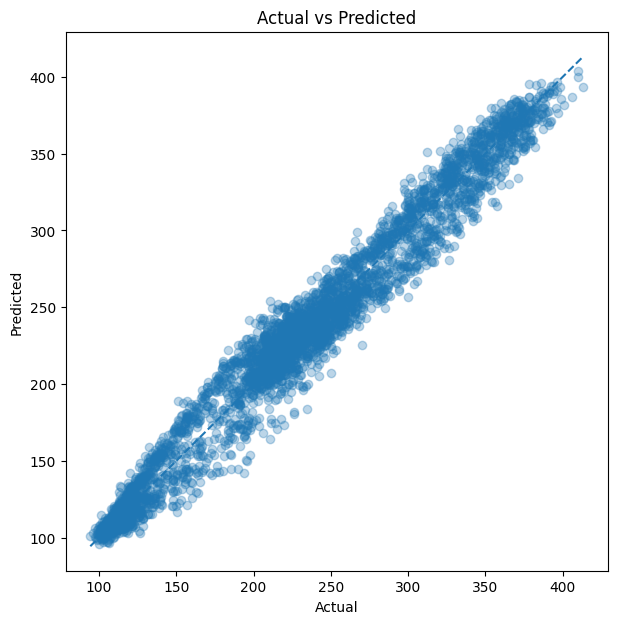

In [16]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.3
)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    "--"

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [18]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [20]:
from pathlib import Path

Path("../outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

Path("../outputs/figures").mkdir(
    parents=True,
    exist_ok=True
)

Path("../outputs/models").mkdir(
    parents=True,
    exist_ok=True
)

print("Output folders created successfully.")

Output folders created successfully.


In [21]:
from pathlib import Path

Path("../outputs/models").mkdir(
    parents=True,
    exist_ok=True
)

In [22]:
import joblib

joblib.dump(
    model,
    "../outputs/models/linear_regression_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
